Import libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

Upload your CSV

In [16]:
from google.colab import files

uploaded = files.upload()

Saving samplesuperstore.csv to samplesuperstore.csv


Read the dataset

In [19]:
df = pd.read_csv('samplesuperstore.csv')

In [21]:
uploaded.keys()

dict_keys(['samplesuperstore.csv'])

In [22]:
df = pd.read_csv(list(uploaded.keys())[0])

Data Verify

In [23]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [24]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
10189,10190,US-2026-143259,12/30/2026,1/3/2027,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,10009,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910
10190,10191,US-2026-115427,12/30/2026,1/3/2027,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,California,94533,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,20.720,2,0.2,6.4750
10191,10192,US-2026-156720,12/30/2026,1/3/2027,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,Colorado,80538,West,OFF-FA-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,3.024,3,0.2,-0.6048
10192,10193,US-2026-143259,12/30/2026,1/3/2027,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,10009,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279
10193,10194,CA-2026-143500,12/30/2026,1/3/2027,Standard Class,HO-15230,Harry Olson,Consumer,Canada,Charlottetown,Prince Edward Island,C0A,East,OFF-BI-10004040,Office Supplies,Binders,Wilson Jones Impact Binders,3.024,3,0.2,-0.6048


In [25]:
df.shape

(10194, 21)

In [26]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country/Region',
 'City',
 'State/Province',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

Dataset information

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [28]:
missing = df.isnull().sum()

missing[missing > 0]

,0


In [29]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': missing_percentage
})

missing_summary[missing_summary['Missing Values'] > 0]

,Missing Values,Missing Percentage


In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df[df.duplicated()].head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [32]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country/Region,object
City,object


Convert dates

In [33]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

In [34]:
print(df[['Order Date', 'Ship Date']].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


Check date range

In [35]:
print("Order Date Range:")
print("Start:", df['Order Date'].min())
print("End:", df['Order Date'].max())

print("\nShip Date Range:")
print("Start:", df['Ship Date'].min())
print("End:", df['Ship Date'].max())

Order Date Range:
Start: 2023-01-03 00:00:00
End: 2026-12-30 00:00:00

Ship Date Range:
Start: 2023-01-07 00:00:00
End: 2027-01-05 00:00:00


In [36]:
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe()

,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000
mean,228.225854,3.791838,0.155385,28.673417
std,619.906839,2.228317,0.206249,232.465115
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.220000,2.000000,0.000000,1.760800
50%,53.910000,3.000000,0.200000,8.690000
75%,209.500000,5.000000,0.200000,29.297925
max,22638.480000,14.000000,0.800000,8399.976000


In [37]:
print("Sales <= 0:", (df['Sales'] <= 0).sum())
print("Quantity <= 0:", (df['Quantity'] <= 0).sum())
print("Discount < 0:", (df['Discount'] < 0).sum())
print("Discount > 1:", (df['Discount'] > 1).sum())

Sales <= 0: 0
Quantity <= 0: 0
Discount < 0: 0
Discount > 1: 0


In [38]:
categorical_columns = [
    'Ship Mode',
    'Segment',
    'Country/Region',
    'Region',
    'Category',
    'Sub-Category'
]

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Ship Mode ---
Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: count, dtype: int64

--- Segment ---
Segment
Consumer       5281
Corporate      3090
Home Office    1823
Name: count, dtype: int64

--- Country/Region ---
Country/Region
United States    9994
Canada            200
Name: count, dtype: int64

--- Region ---
Region
West       3253
East       2986
Central    2335
South      1620
Name: count, dtype: int64

--- Category ---
Category
Office Supplies    6128
Furniture          2201
Technology         1865
Name: count, dtype: int64

--- Sub-Category ---
Sub-Category
Binders        1548
Paper          1384
Furnishings    1009
Phones          903
Storage         856
Art             821
Accessories     775
Chairs          634
Appliances      474
Labels          368
Tables          326
Envelopes       256
Bookcases       232
Fasteners       229
Supplies        192
Machines        117
Copiers          70
Name: count, dtype: 

In [39]:
print("Unique Orders:", df['Order ID'].nunique())
print("Unique Customers:", df['Customer ID'].nunique())
print("Unique Products:", df['Product ID'].nunique())
print("Unique Categories:", df['Category'].nunique())
print("Unique Sub-Categories:", df['Sub-Category'].nunique())
print("Unique Regions:", df['Region'].nunique())

Unique Orders: 5111
Unique Customers: 804
Unique Products: 1862
Unique Categories: 3
Unique Sub-Categories: 17
Unique Regions: 4


In [40]:
data_quality = pd.DataFrame({
    'Metric': [
        'Total Rows',
        'Total Columns',
        'Duplicate Rows',
        'Missing Values',
        'Unique Orders',
        'Unique Customers',
        'Unique Products'
    ],
    'Value': [
        df.shape[0],
        df.shape[1],
        df.duplicated().sum(),
        df.isnull().sum().sum(),
        df['Order ID'].nunique(),
        df['Customer ID'].nunique(),
        df['Product ID'].nunique()
    ]
})

data_quality

,Metric,Value
0,Total Rows,10194
1,Total Columns,21
2,Duplicate Rows,0
3,Missing Values,0
4,Unique Orders,5111
5,Unique Customers,804
6,Unique Products,1862


Clean + Create KPI Dataset

In [43]:
df_clean = df.copy()

# 1. Convert dates
df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'], errors='coerce')
df_clean['Ship Date'] = pd.to_datetime(df_clean['Ship Date'], errors='coerce')

# 2. Remove exact duplicate rows
df_clean = df_clean.drop_duplicates()

# 3. Remove rows with missing critical values
critical_cols = ['Order ID', 'Order Date', 'Customer ID',
                 'Product ID', 'Sales', 'Quantity', 'Profit']

df_clean = df_clean.dropna(subset=critical_cols)

# 4. Create time dimensions
df_clean['Year'] = df_clean['Order Date'].dt.year
df_clean['Month'] = df_clean['Order Date'].dt.month
df_clean['Month Name'] = df_clean['Order Date'].dt.strftime('%B')
df_clean['Year-Month'] = df_clean['Order Date'].dt.to_period('M').astype(str)
df_clean['Quarter'] = 'Q' + df_clean['Order Date'].dt.quarter.astype(str)

# 5. Create profit margin
df_clean['Profit Margin %'] = (
    df_clean['Profit'] / df_clean['Sales'] * 100
).round(2)

# 6. Create Order Value at transaction level
df_clean['Order Value'] = df_clean['Sales']

# 7. Sort by date
df_clean = df_clean.sort_values('Order Date')

total_revenue = df_clean['Sales'].sum()
total_profit = df_clean['Profit'].sum()
total_orders = df_clean['Order ID'].nunique()
total_customers = df_clean['Customer ID'].nunique()
total_quantity = df_clean['Quantity'].sum()
aov = total_revenue / total_orders
profit_margin = total_profit / total_revenue * 100

print("SALES PERFORMANCE KPIs")
print(f"Total Revenue     : ${total_revenue:,.2f}")
print(f"Total Profit      : ${total_profit:,.2f}")
print(f"Profit Margin     : {profit_margin:.2f}%")
print(f"Total Orders      : {total_orders:,}")
print(f"Total Customers   : {total_customers:,}")
print(f"Total Quantity    : {total_quantity:,}")
print(f"Average Order Value: ${aov:,.2f}")

print("\n DATASET ")
print("Original rows :", len(df))
print("Cleaned rows  :", len(df_clean))
print("Removed rows  :", len(df) - len(df_clean))
print("\nDATE RANGE")
print("From:", df_clean['Order Date'].min().date())
print("To  :", df_clean['Order Date'].max().date())

SALES PERFORMANCE KPIs
Total Revenue     : $2,326,534.35
Total Profit      : $292,296.81
Profit Margin     : 12.56%
Total Orders      : 5,111
Total Customers   : 804
Total Quantity    : 38,654
Average Order Value: $455.20

 DATASET 
Original rows : 10194
Cleaned rows  : 10194
Removed rows  : 0

DATE RANGE
From: 2023-01-03
To  : 2026-12-30


Sales Trends + MoM Growth + Region + Category

In [44]:
# ---------- MONTHLY PERFORMANCE ----------
monthly = (
    df_clean.groupby('Year-Month')
    .agg(
        Revenue=('Sales', 'sum'),
        Profit=('Profit', 'sum'),
        Orders=('Order ID', 'nunique'),
        Customers=('Customer ID', 'nunique')
    )
    .reset_index()
)

# MoM growth
monthly['Revenue MoM %'] = monthly['Revenue'].pct_change().mul(100).round(2)
monthly['Profit MoM %'] = monthly['Profit'].pct_change().mul(100).round(2)

# Average Order Value
monthly['AOV'] = (monthly['Revenue'] / monthly['Orders']).round(2)

# ---------- REGIONAL PERFORMANCE ----------
region = (
    df_clean.groupby('Region')
    .agg(
        Revenue=('Sales', 'sum'),
        Profit=('Profit', 'sum'),
        Orders=('Order ID', 'nunique'),
        Customers=('Customer ID', 'nunique'),
        Quantity=('Quantity', 'sum')
    )
    .reset_index()
)

region['Profit Margin %'] = (
    region['Profit'] / region['Revenue'] * 100
).round(2)

region['AOV'] = (
    region['Revenue'] / region['Orders']
).round(2)

region = region.sort_values('Revenue', ascending=False)

# ---------- CATEGORY PERFORMANCE ----------
category = (
    df_clean.groupby('Category')
    .agg(
        Revenue=('Sales', 'sum'),
        Profit=('Profit', 'sum'),
        Orders=('Order ID', 'nunique'),
        Quantity=('Quantity', 'sum')
    )
    .reset_index()
)

category['Profit Margin %'] = (
    category['Profit'] / category['Revenue'] * 100
).round(2)

category = category.sort_values('Revenue', ascending=False)

# ---------- SUB-CATEGORY PERFORMANCE ----------
subcategory = (
    df_clean.groupby('Sub-Category')
    .agg(
        Revenue=('Sales', 'sum'),
        Profit=('Profit', 'sum'),
        Quantity=('Quantity', 'sum')
    )
    .reset_index()
)

subcategory['Profit Margin %'] = (
    subcategory['Profit'] / subcategory['Revenue'] * 100
).round(2)

subcategory = subcategory.sort_values('Revenue', ascending=False)

# ---------- TOP 10 PRODUCTS ----------
top_products = (
    df_clean.groupby(['Product ID', 'Product Name'])
    .agg(
        Revenue=('Sales', 'sum'),
        Profit=('Profit', 'sum'),
        Quantity=('Quantity', 'sum')
    )
    .reset_index()
    .sort_values('Revenue', ascending=False)
    .head(10)
)

# ---------- TOP 10 CUSTOMERS ----------
top_customers = (
    df_clean.groupby(['Customer ID', 'Customer Name'])
    .agg(
        Revenue=('Sales', 'sum'),
        Profit=('Profit', 'sum'),
        Orders=('Order ID', 'nunique')
    )
    .reset_index()
    .sort_values('Revenue', ascending=False)
    .head(10)
)

# DISPLAY RESULTS

print("========== MONTHLY PERFORMANCE ==========")
display(monthly)

print("\n========== REGIONAL PERFORMANCE ==========")
display(region)

print("\n========== CATEGORY PERFORMANCE ==========")
display(category)

print("\n========== SUB-CATEGORY PERFORMANCE ==========")
display(subcategory)

print("\n========== TOP 10 PRODUCTS ==========")
display(top_products)

print("\n========== TOP 10 CUSTOMERS ==========")
display(top_customers)

========== MONTHLY PERFORMANCE ==========


,Year-Month,Revenue,Profit,Orders,Customers,Revenue MoM %,Profit MoM %,AOV
0,2023-01,14518.0550,2539.3907,33,33,NaN,NaN,439.94
1,2023-02,4519.8920,862.3084,28,27,-68.87,-66.04,161.42
2,2023-03,56933.9090,693.4499,72,70,1159.63,-19.58,790.75
3,2023-04,28295.3450,3488.8352,66,64,-50.30,403.11,428.72
4,2023-05,26319.7670,3196.3918,72,68,-6.98,-8.38,365.55
5,2023-06,34669.4796,4999.7594,67,64,31.72,56.42,517.45
6,2023-07,33946.3930,-841.4826,65,65,-2.09,-116.83,522.25
7,2023-08,28918.3385,5765.2250,75,73,-14.81,-785.13,385.58
8,2023-09,82670.4288,8593.6302,134,121,185.88,49.06,616.94
9,2023-10,32413.3390,3469.1749,81,76,-60.79,-59.63,400.16



========== REGIONAL PERFORMANCE ==========


,Region,Revenue,Profit,Orders,Customers,Quantity,Profit Margin %,AOV
3,West,739813.6085,110798.8170,1635,686,12466,14.98,452.49
1,East,691828.1680,94883.2603,1475,685,11159,13.71,469.04
0,Central,503170.6728,39865.3070,1179,629,8820,7.92,426.78
2,South,391721.9050,46749.4303,822,512,6209,11.93,476.55



========== CATEGORY PERFORMANCE ==========


...

,Sub-Category,Revenue,Profit,Quantity,Profit Margin %
5,Chairs,335768.2490,27223.5323,2431,8.11
13,Phones,331842.6400,45050.8265,3357,13.58
14,Storage,224644.5540,21285.1115,3191,9.48
16,Tables,208020.1820,-17753.2061,1261,-8.53
3,Binders,207354.8810,31426.1003,6071,15.16
11,Machines,189925.0310,3461.9769,442,1.82
0,Accessories,167380.3180,41936.6357,2976,25.05
6,Copiers,150745.2900,56093.9365,242,37.21
4,Bookcases,115361.2043,-3632.0736,878,-3.15
1,Appliances,108213.1850,18329.4844,1750,16.94



========== TOP 10 PRODUCTS ==========


,Product ID,Product Name,Revenue,Profit,Quantity
1640,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61599.824,2.519993e+04,20
787,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,7.753039e+03,31
1669,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1.811078e+03,6
82,FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,21870.576,1.136868e-13,39
701,OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,19823.479,2.233505e+03,37
667,OFF-BI-10000545,GBC Ibimaster 500 Manual ProClick Binding System,19024.500,7.609800e+02,48
1630,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,18839.686,6.983884e+03,38
1657,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Printer ...,18374.895,4.094977e+03,12
858,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.068,-1.878166e+03,27
1443,OFF-SU-10000151,High Speed Automatic Electric Letter Opener,17030.312,-2.620048e+02,11



========== TOP 10 CUSTOMERS ==========


,Customer ID,Customer Name,Revenue,Profit,Orders
711,SM-20320,Sean Miller,25043.050,-1980.7393,5
752,TC-20980,Tamara Chand,19052.218,8981.3239,5
632,RB-19360,Raymond Buch,15117.339,6976.0959,6
741,TA-21385,Tom Ashbrook,14595.620,4703.7883,4
6,AB-10105,Adrian Barton,14473.571,5444.8055,10
443,KL-16645,Ken Lonsdale,14175.229,806.8550,12
680,SC-20095,Sanjit Chand,14142.334,5757.4119,9
328,HL-15040,Hunter Lopez,12873.298,5622.4292,6
694,SE-20110,Sanjit Engle,12209.438,2650.6769,11
132,CC-12370,Christopher Conant,12129.072,2177.0493,5


Create the Sales Analysis Charts

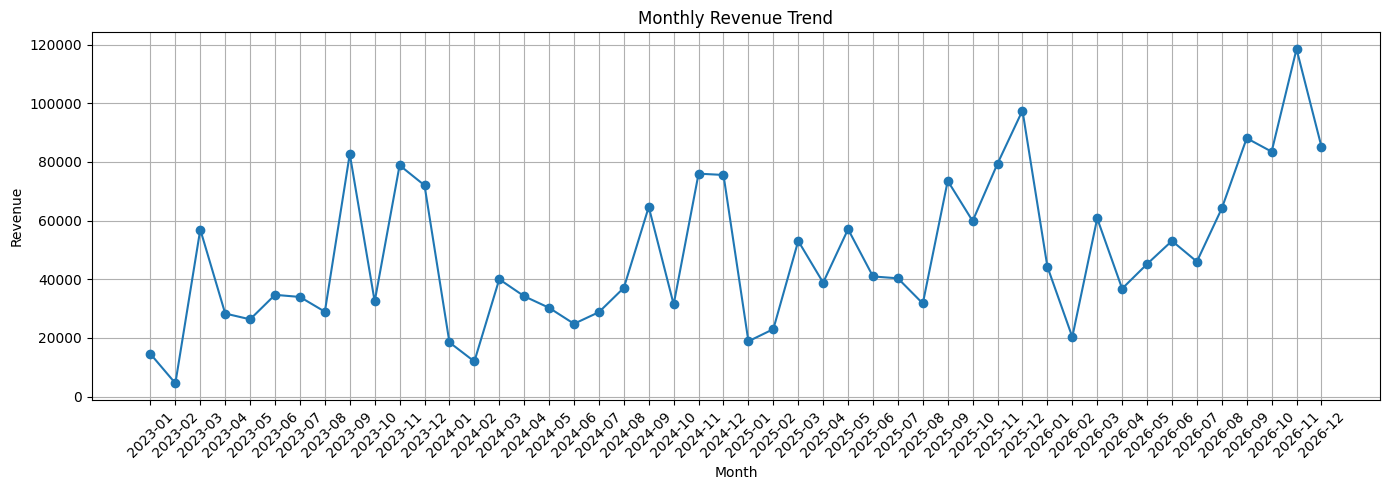

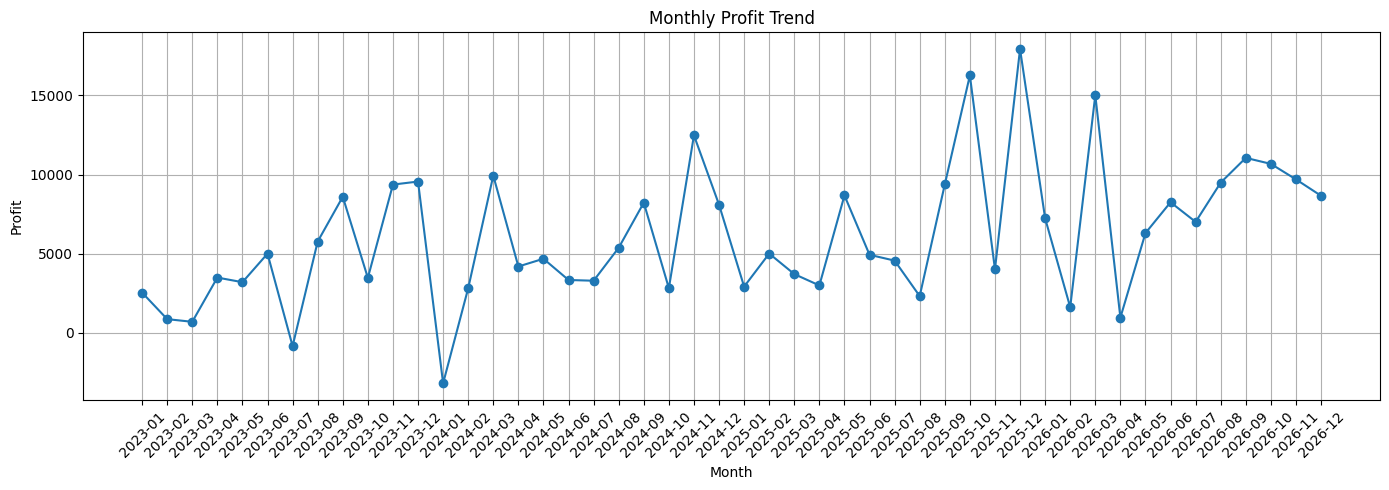

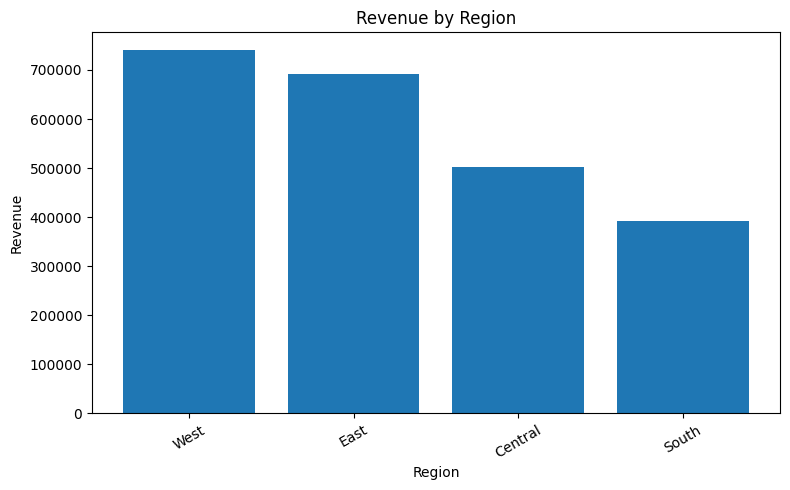

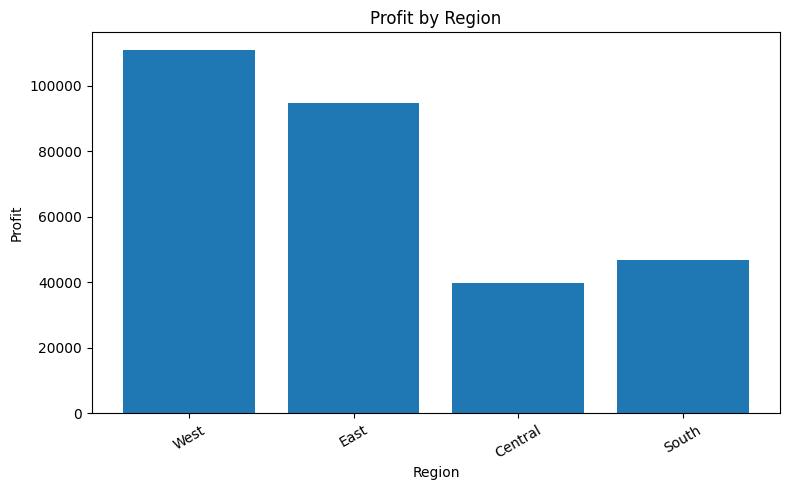

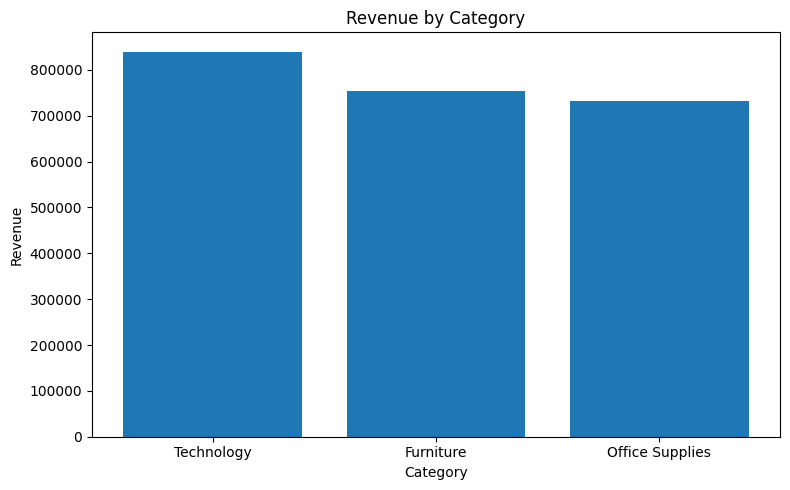

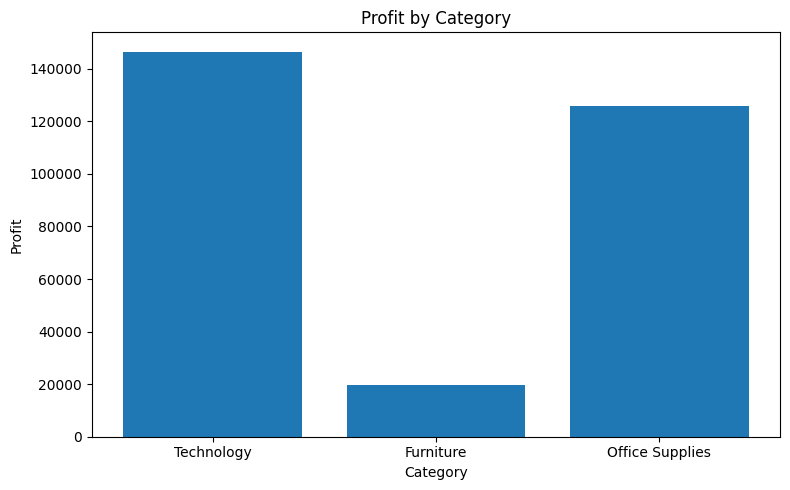

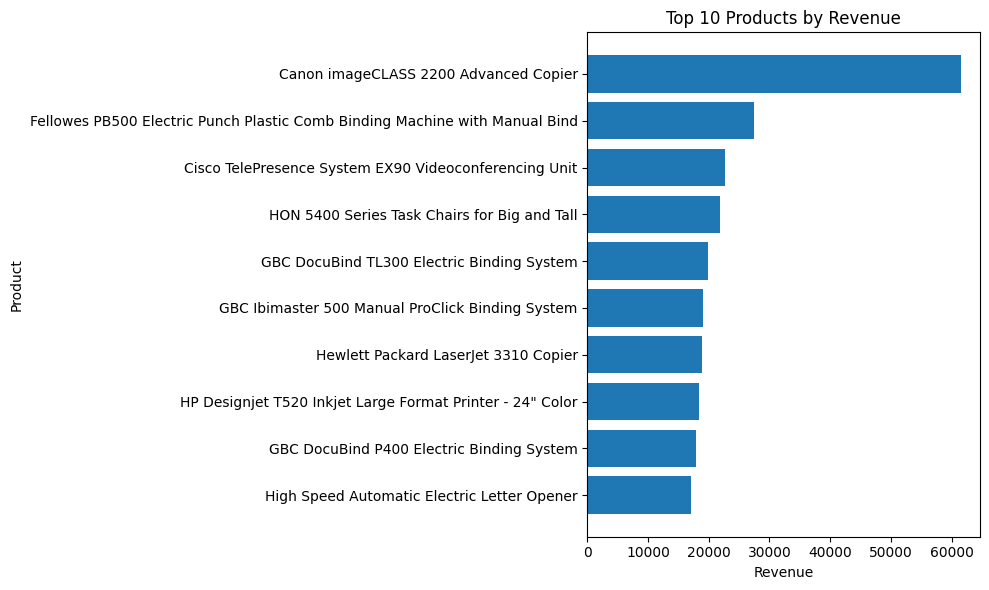

In [45]:
import matplotlib.pyplot as plt

# ---------- 1. MONTHLY REVENUE ----------
plt.figure(figsize=(14, 5))
plt.plot(monthly['Year-Month'], monthly['Revenue'], marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


# ---------- 2. MONTHLY PROFIT ----------
plt.figure(figsize=(14, 5))
plt.plot(monthly['Year-Month'], monthly['Profit'], marker='o')
plt.title('Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


# ---------- 3. REVENUE BY REGION ----------
plt.figure(figsize=(8, 5))
plt.bar(region['Region'], region['Revenue'])
plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Revenue')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ---------- 4. PROFIT BY REGION ----------
plt.figure(figsize=(8, 5))
plt.bar(region['Region'], region['Profit'])
plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ---------- 5. REVENUE BY CATEGORY ----------
plt.figure(figsize=(8, 5))
plt.bar(category['Category'], category['Revenue'])
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()


# ---------- 6. PROFIT BY CATEGORY ----------
plt.figure(figsize=(8, 5))
plt.bar(category['Category'], category['Profit'])
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()


# ---------- 7. TOP 10 PRODUCTS ----------
top_products_plot = top_products.sort_values('Revenue')

plt.figure(figsize=(10, 6))
plt.barh(top_products_plot['Product Name'], top_products_plot['Revenue'])
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

Export the datasets

In [46]:

import os

os.makedirs('sales_project_data', exist_ok=True)

df_clean.to_csv(
    'sales_project_data/sales_cleaned.csv',
    index=False
)

monthly.to_csv(
    'sales_project_data/monthly_performance.csv',
    index=False
)

region.to_csv(
    'sales_project_data/regional_performance.csv',
    index=False
)

category.to_csv(
    'sales_project_data/category_performance.csv',
    index=False
)

subcategory.to_csv(
    'sales_project_data/subcategory_performance.csv',
    index=False
)

top_products.to_csv(
    'sales_project_data/top_products.csv',
    index=False
)

top_customers.to_csv(
    'sales_project_data/top_customers.csv',
    index=False
)

print("✅ All analytical datasets exported successfully!")
print("\nFiles created:")

for file in os.listdir('sales_project_data'):
    print("📁", file)

✅ All analytical datasets exported successfully!

Files created:
📁 regional_performance.csv
📁 sales_cleaned.csv
📁 top_customers.csv
📁 subcategory_performance.csv
📁 monthly_performance.csv
📁 top_products.csv
📁 category_performance.csv


Load Sales Data into SQL

In [47]:

import sqlite3
import pandas as pd

# Create SQLite database
conn = sqlite3.connect('sales_performance.db')

# Load cleaned data into SQL table
df_clean.to_sql(
    'sales',
    conn,
    if_exists='replace',
    index=False
)

print("✅ Sales data loaded into SQL successfully!")

# Check number of rows
result = pd.read_sql_query(
    "SELECT COUNT(*) AS total_rows FROM sales",
    conn
)

display(result)

# Preview SQL table
preview = pd.read_sql_query(
    "SELECT * FROM sales LIMIT 5",
    conn
)

display(preview)

✅ Sales data loaded into SQL successfully!


,total_rows
0,10194


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Year-Month,Quarter,Profit Margin %,Order Value
0,1,US-2023-103800,2023-01-03 00:00:00,2023-01-07 00:00:00,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023,1,January,2023-01,Q1,33.75,16.448
1,2,US-2023-112326,2023-01-04 00:00:00,2023-01-08 00:00:00,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023,1,January,2023-01,Q1,-155.00,3.540
2,3,US-2023-112326,2023-01-04 00:00:00,2023-01-08 00:00:00,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717,2023,1,January,2023-01,Q1,36.25,11.784
3,4,US-2023-112326,2023-01-04 00:00:00,2023-01-08 00:00:00,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,2023,1,January,2023-01,Q1,-23.75,272.736
4,5,US-2023-141817,2023-01-05 00:00:00,2023-01-12 00:00:00,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,2023,1,January,2023-01,Q1,25.00,19.536


Core SQL Business Analysis

In [48]:

queries = {

"Total Revenue": """
SELECT ROUND(SUM(Sales), 2) AS Total_Revenue
FROM sales;
""",

"Total Profit": """
SELECT ROUND(SUM(Profit), 2) AS Total_Profit
FROM sales;
""",

"Total Orders": """
SELECT COUNT(DISTINCT "Order ID") AS Total_Orders
FROM sales;
""",

"Total Customers": """
SELECT COUNT(DISTINCT "Customer ID") AS Total_Customers
FROM sales;
""",

"Average Order Value": """
SELECT ROUND(
    SUM(Sales) / COUNT(DISTINCT "Order ID"), 2
) AS Average_Order_Value
FROM sales;
""",

"Profit Margin": """
SELECT ROUND(
    SUM(Profit) * 100.0 / SUM(Sales), 2
) AS Profit_Margin_Percent
FROM sales;
""",

"Revenue by Region": """
SELECT
    Region,
    ROUND(SUM(Sales), 2) AS Revenue,
    ROUND(SUM(Profit), 2) AS Profit
FROM sales
GROUP BY Region
ORDER BY Revenue DESC;
""",

"Revenue by Category": """
SELECT
    Category,
    ROUND(SUM(Sales), 2) AS Revenue,
    ROUND(SUM(Profit), 2) AS Profit
FROM sales
GROUP BY Category
ORDER BY Revenue DESC;
""",

"Top 10 Products": """
SELECT
    "Product Name",
    ROUND(SUM(Sales), 2) AS Revenue,
    ROUND(SUM(Profit), 2) AS Profit
FROM sales
GROUP BY "Product Name"
ORDER BY Revenue DESC
LIMIT 10;
"""
}

for name, query in queries.items():
    print(f"\n========== {name.upper()} ==========")
    display(pd.read_sql_query(query, conn))


========== TOTAL REVENUE ==========


,Total_Revenue
0,2326534.35



========== TOTAL PROFIT ==========


,Total_Profit
0,292296.81



========== TOTAL ORDERS ==========


...

,Region,Revenue,Profit
0,West,739813.61,110798.82
1,East,691828.17,94883.26
2,Central,503170.67,39865.31
3,South,391721.91,46749.43



========== REVENUE BY CATEGORY ==========


,Category,Revenue,Profit
0,Technology,839893.28,146543.38
1,Furniture,754747.76,19730.00
2,Office Supplies,731893.31,126023.44



========== TOP 10 PRODUCTS ==========


,Product Name,Revenue,Profit
0,Canon imageCLASS 2200 Advanced Copier,61599.82,25199.93
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.38,7753.04
2,Cisco TelePresence System EX90 Videoconferenci...,22638.48,-1811.08
3,HON 5400 Series Task Chairs for Big and Tall,21870.58,0.00
4,GBC DocuBind TL300 Electric Binding System,19823.48,2233.51
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.50,760.98
6,Hewlett Packard LaserJet 3310 Copier,18839.69,6983.88
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.90,4094.98
8,GBC DocuBind P400 Electric Binding System,17965.07,-1878.17
9,High Speed Automatic Electric Letter Opener,17030.31,-262.00


Monthly SQL Analysis + MoM Growth

In [49]:
monthly_sql = """
WITH monthly_sales AS (
    SELECT
        strftime('%Y-%m', "Order Date") AS Year_Month,
        SUM(Sales) AS Revenue,
        SUM(Profit) AS Profit,
        COUNT(DISTINCT "Order ID") AS Orders
    FROM sales
    GROUP BY strftime('%Y-%m', "Order Date")
)

SELECT
    Year_Month,
    ROUND(Revenue, 2) AS Revenue,
    ROUND(Profit, 2) AS Profit,
    Orders,
    ROUND(
        (Revenue - LAG(Revenue) OVER (ORDER BY Year_Month))
        * 100.0 /
        LAG(Revenue) OVER (ORDER BY Year_Month),
        2
    ) AS Revenue_MoM_Growth_Percent
FROM monthly_sales
ORDER BY Year_Month;
"""

monthly_sql_result = pd.read_sql_query(monthly_sql, conn)

display(monthly_sql_result)

,Year_Month,Revenue,Profit,Orders,Revenue_MoM_Growth_Percent
0,2023-01,14518.06,2539.39,33,NaN
1,2023-02,4519.89,862.31,28,-68.87
2,2023-03,56933.91,693.45,72,1159.63
3,2023-04,28295.35,3488.84,66,-50.30
4,2023-05,26319.77,3196.39,72,-6.98
5,2023-06,34669.48,4999.76,67,31.72
6,2023-07,33946.39,-841.48,65,-2.09
7,2023-08,28918.34,5765.23,75,-14.81
8,2023-09,82670.43,8593.63,134,185.88
9,2023-10,32413.34,3469.17,81,-60.79


Save SQL results

In [50]:
monthly_sql_result.to_csv(
    'sales_project_data/monthly_sql_analysis.csv',
    index=False
)

# Save SQL database
conn.commit()

print("✅ SQL analysis completed!")
print("✅ Database saved as: sales_performance.db")
print("✅ Monthly SQL analysis exported.")

✅ SQL analysis completed!
✅ Database saved as: sales_performance.db
✅ Monthly SQL analysis exported.


In [51]:
from google.colab import files

df_clean.to_csv('sales_cleaned.csv', index=False)

files.download('sales_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Build the Dashboard in Google Colab

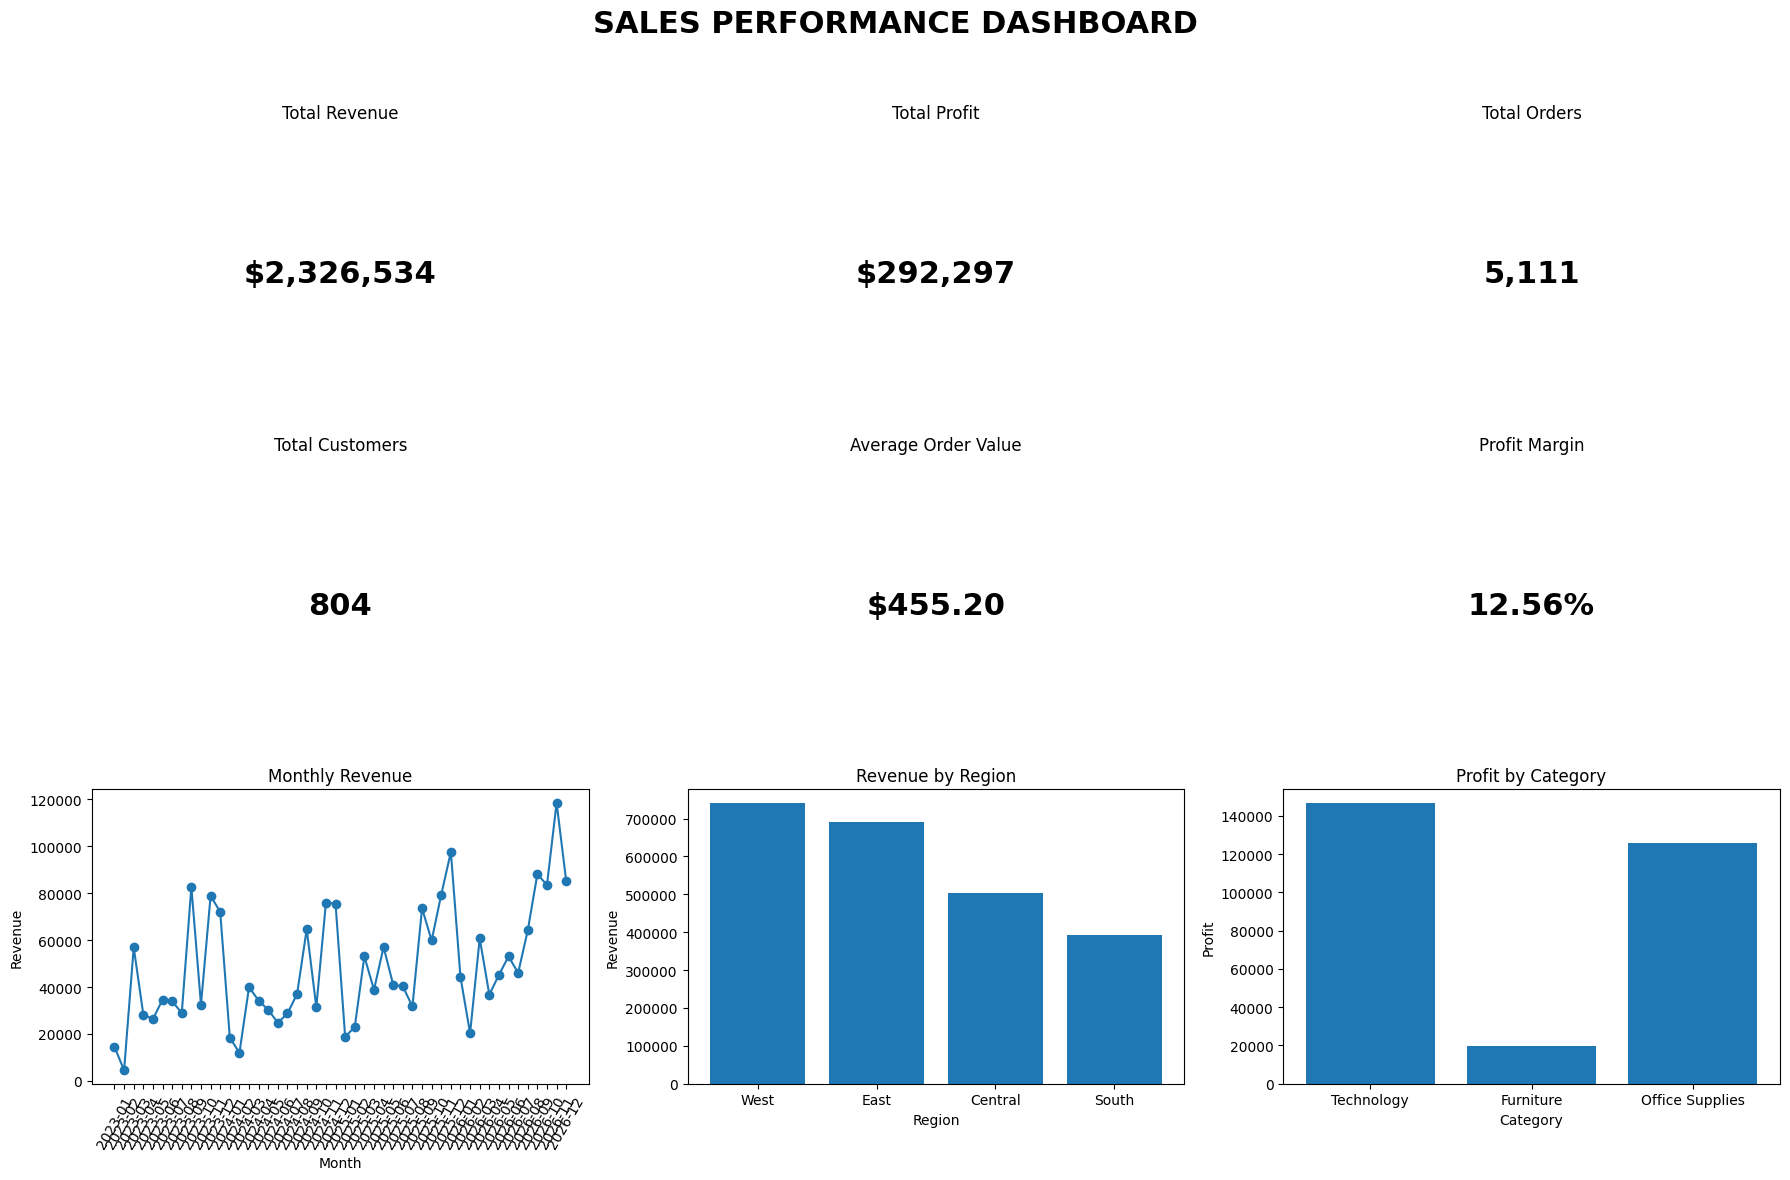

In [52]:

import matplotlib.pyplot as plt

# Create dashboard
fig = plt.figure(figsize=(18, 12))

# ---------- KPI VALUES ----------
total_revenue = df_clean['Sales'].sum()
total_profit = df_clean['Profit'].sum()
total_orders = df_clean['Order ID'].nunique()
total_customers = df_clean['Customer ID'].nunique()
aov = total_revenue / total_orders
profit_margin = (total_profit / total_revenue) * 100

# ---------- TITLE ----------
fig.suptitle(
    'SALES PERFORMANCE DASHBOARD',
    fontsize=22,
    fontweight='bold'
)

# ---------- KPI 1 ----------
ax1 = plt.subplot(3, 3, 1)
ax1.text(0.5, 0.5, f'${total_revenue:,.0f}',
         ha='center', va='center', fontsize=22,
         fontweight='bold')
ax1.set_title('Total Revenue')
ax1.axis('off')

# ---------- KPI 2 ----------
ax2 = plt.subplot(3, 3, 2)
ax2.text(0.5, 0.5, f'${total_profit:,.0f}',
         ha='center', va='center', fontsize=22,
         fontweight='bold')
ax2.set_title('Total Profit')
ax2.axis('off')

# ---------- KPI 3 ----------
ax3 = plt.subplot(3, 3, 3)
ax3.text(0.5, 0.5, f'{total_orders:,}',
         ha='center', va='center', fontsize=22,
         fontweight='bold')
ax3.set_title('Total Orders')
ax3.axis('off')

# ---------- KPI 4 ----------
ax4 = plt.subplot(3, 3, 4)
ax4.text(0.5, 0.5, f'{total_customers:,}',
         ha='center', va='center', fontsize=22,
         fontweight='bold')
ax4.set_title('Total Customers')
ax4.axis('off')

# ---------- KPI 5 ----------
ax5 = plt.subplot(3, 3, 5)
ax5.text(0.5, 0.5, f'${aov:,.2f}',
         ha='center', va='center', fontsize=22,
         fontweight='bold')
ax5.set_title('Average Order Value')
ax5.axis('off')

# ---------- KPI 6 ----------
ax6 = plt.subplot(3, 3, 6)
ax6.text(0.5, 0.5, f'{profit_margin:.2f}%',
         ha='center', va='center', fontsize=22,
         fontweight='bold')
ax6.set_title('Profit Margin')
ax6.axis('off')

# ---------- MONTHLY REVENUE ----------
ax7 = plt.subplot(3, 3, 7)
ax7.plot(monthly['Year-Month'], monthly['Revenue'], marker='o')
ax7.set_title('Monthly Revenue')
ax7.set_xlabel('Month')
ax7.set_ylabel('Revenue')
ax7.tick_params(axis='x', rotation=60)

# ---------- REGION ----------
ax8 = plt.subplot(3, 3, 8)
ax8.bar(region['Region'], region['Revenue'])
ax8.set_title('Revenue by Region')
ax8.set_xlabel('Region')
ax8.set_ylabel('Revenue')

# ---------- CATEGORY ----------
ax9 = plt.subplot(3, 3, 9)
ax9.bar(category['Category'], category['Profit'])
ax9.set_title('Profit by Category')
ax9.set_xlabel('Category')
ax9.set_ylabel('Profit')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Advanced Business Insights

In [53]:

# 1. SUB-CATEGORY PROFITABILITY
subcategory_analysis = (
    df_clean.groupby('Sub-Category')
    .agg(
        Revenue=('Sales', 'sum'),
        Profit=('Profit', 'sum'),
        Quantity=('Quantity', 'sum'),
        Orders=('Order ID', 'nunique')
    )
    .reset_index()
)

subcategory_analysis['Profit Margin %'] = (
    subcategory_analysis['Profit'] /
    subcategory_analysis['Revenue'] * 100
).round(2)

subcategory_analysis = subcategory_analysis.sort_values(
    'Profit', ascending=False
)

# 2. DISCOUNT VS PROFIT
discount_analysis = (
    df_clean.groupby('Discount')
    .agg(
        Revenue=('Sales', 'sum'),
        Profit=('Profit', 'sum'),
        Orders=('Order ID', 'nunique')
    )
    .reset_index()
)

discount_analysis['Profit Margin %'] = (
    discount_analysis['Profit'] /
    discount_analysis['Revenue'] * 100
).round(2)

# 3. LOSS-MAKING PRODUCTS
product_analysis = (
    df_clean.groupby(['Product ID', 'Product Name'])
    .agg(
        Revenue=('Sales', 'sum'),
        Profit=('Profit', 'sum'),
        Quantity=('Quantity', 'sum')
    )
    .reset_index()
)

loss_products = (
    product_analysis[
        product_analysis['Profit'] < 0
    ]
    .sort_values('Profit')
)

# 4. HIGH REVENUE BUT LOW PROFIT PRODUCTS
revenue_median = product_analysis['Revenue'].median()
profit_median = product_analysis['Profit'].median()

high_revenue_low_profit = product_analysis[
    (product_analysis['Revenue'] >= revenue_median) &
    (product_analysis['Profit'] < profit_median)
].sort_values('Revenue', ascending=False)

# 5. REGIONAL PROFITABILITY
regional_analysis = (
    df_clean.groupby('Region')
    .agg(
        Revenue=('Sales', 'sum'),
        Profit=('Profit', 'sum'),
        Orders=('Order ID', 'nunique'),
        Customers=('Customer ID', 'nunique'),
        Quantity=('Quantity', 'sum')
    )
    .reset_index()
)

regional_analysis['Profit Margin %'] = (
    regional_analysis['Profit'] /
    regional_analysis['Revenue'] * 100
).round(2)

regional_analysis = regional_analysis.sort_values(
    'Revenue', ascending=False
)

# DISPLAY RESULTS

print("========== SUB-CATEGORY PROFITABILITY ==========")
display(subcategory_analysis)

print("\n========== DISCOUNT VS PROFIT ==========")
display(discount_analysis)

print("\n========== LOSS-MAKING PRODUCTS ==========")
display(loss_products.head(15))

print("\n========== HIGH REVENUE / LOW PROFIT PRODUCTS ==========")
display(high_revenue_low_profit.head(15))

print("\n========== REGIONAL PROFITABILITY ==========")
display(regional_analysis)

========== SUB-CATEGORY PROFITABILITY ==========


,Sub-Category,Revenue,Profit,Quantity,Orders,Profit Margin %
6,Copiers,150745.2900,56093.9365,242,70,37.21
13,Phones,331842.6400,45050.8265,3357,826,13.58
0,Accessories,167380.3180,41936.6357,2976,718,25.05
12,Paper,79540.5380,34511.5070,5207,1205,43.39
3,Binders,207354.8810,31426.1003,6071,1339,15.16
5,Chairs,335768.2490,27223.5323,2431,591,8.11
14,Storage,224644.5540,21285.1115,3191,787,9.48
1,Appliances,108213.1850,18329.4844,1750,459,16.94
9,Furnishings,95598.1260,13891.7430,3799,919,14.53
7,Envelopes,16528.3620,6988.0247,914,251,42.28



========== DISCOUNT VS PROFIT ==========


,Discount,Revenue,Profit,Orders,Profit Margin %
0,0.00,1.105324e+06,326718.5872,2714,29.56
1,0.10,5.495250e+04,9099.9700,91,16.56
2,0.15,2.755852e+04,1418.9915,51,5.15
3,0.20,7.739394e+05,91079.9517,2440,11.77
4,0.30,1.044741e+05,-10513.4456,214,-10.06
5,0.32,1.449346e+04,-2391.1377,27,-16.50
6,0.40,1.164978e+05,-23086.3742,186,-19.82
7,0.45,5.484974e+03,-2493.1111,10,-45.45
8,0.50,5.891854e+04,-20506.4281,64,-34.80
9,0.60,7.105940e+03,-6164.3472,138,-86.75



========== LOSS-MAKING PRODUCTS ==========


,Product ID,Product Name,Revenue,Profit,Quantity
1645,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,9
1650,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18
1696,TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4
326,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.640,-2876.1156,27
344,FUR-TA-10001889,Bush Advantage Collection Racetrack Conference...,9544.725,-1934.3976,33
858,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,27
1669,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1811.0784,6
1465,OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Op...,16656.200,-1299.1836,22
346,FUR-TA-10001950,Balt Solid Wood Round Tables,6518.754,-1201.0581,19
375,FUR-TA-10004289,BoxOffice By Design Rectangular and Half-Moon ...,1706.250,-1148.4375,15



========== HIGH REVENUE / LOW PROFIT PRODUCTS ==========


,Product ID,Product Name,Revenue,Profit,Quantity
1669,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,22638.4800,-1.811078e+03,6
82,FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,21870.5760,1.136868e-13,39
858,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.0680,-1.878166e+03,27
1443,OFF-SU-10000151,High Speed Automatic Electric Letter Opener,17030.3120,-2.620048e+02,11
1650,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,16829.9010,-4.589973e+03,18
1465,OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Op...,16656.2000,-1.299184e+03,22
49,FUR-BO-10004834,"Riverside Palais Royal Lawyers Bookcase, Royal...",15610.9656,-6.695448e+02,24
363,FUR-TA-10003473,Bretford Rectangular Conference Table Tops,13565.5715,-3.593541e+02,53
1645,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,11099.9630,-8.879970e+03,9
326,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.6400,-2.876116e+03,27



========== REGIONAL PROFITABILITY ==========


,Region,Revenue,Profit,Orders,Customers,Quantity,Profit Margin %
3,West,739813.6085,110798.8170,1635,686,12466,14.98
1,East,691828.1680,94883.2603,1475,685,11159,13.71
0,Central,503170.6728,39865.3070,1179,629,8820,7.92
2,South,391721.9050,46749.4303,822,512,6209,11.93


Automatically generate an Insight Summary

In [54]:

best_revenue_region = regional_analysis.loc[
    regional_analysis['Revenue'].idxmax()
]

best_profit_region = regional_analysis.loc[
    regional_analysis['Profit'].idxmax()
]

best_margin_region = regional_analysis.loc[
    regional_analysis['Profit Margin %'].idxmax()
]

best_category = category.loc[
    category['Revenue'].idxmax()
]

best_profit_category = category.loc[
    category['Profit'].idxmax()
]

best_subcategory = subcategory_analysis.loc[
    subcategory_analysis['Profit'].idxmax()
]

worst_subcategory = subcategory_analysis.loc[
    subcategory_analysis['Profit'].idxmin()
]

best_month = monthly.loc[
    monthly['Revenue'].idxmax()
]

worst_month = monthly.loc[
    monthly['Revenue'].idxmin()
]

print("========== BUSINESS INSIGHT SUMMARY ==========\n")

print(
    f"1. Highest revenue region: "
    f"{best_revenue_region['Region']} "
    f"(${best_revenue_region['Revenue']:,.2f})"
)

print(
    f"2. Highest profit region: "
    f"{best_profit_region['Region']} "
    f"(${best_profit_region['Profit']:,.2f})"
)

print(
    f"3. Highest profit-margin region: "
    f"{best_margin_region['Region']} "
    f"({best_margin_region['Profit Margin %']:.2f}%)"
)

print(
    f"4. Highest revenue category: "
    f"{best_category['Category']} "
    f"(${best_category['Revenue']:,.2f})"
)

print(
    f"5. Highest profit category: "
    f"{best_profit_category['Category']} "
    f"(${best_profit_category['Profit']:,.2f})"
)

print(
    f"6. Most profitable sub-category: "
    f"{best_subcategory['Sub-Category']} "
    f"(${best_subcategory['Profit']:,.2f})"
)

print(
    f"7. Lowest-profit sub-category: "
    f"{worst_subcategory['Sub-Category']} "
    f"(${worst_subcategory['Profit']:,.2f})"
)

print(
    f"8. Highest revenue month: "
    f"{best_month['Year-Month']} "
    f"(${best_month['Revenue']:,.2f})"
)

print(
    f"9. Lowest revenue month: "
    f"{worst_month['Year-Month']} "
    f"(${worst_month['Revenue']:,.2f})"
)

print(
    f"10. Number of loss-making products: "
    f"{len(loss_products):,}"
)

========== BUSINESS INSIGHT SUMMARY ==========

1. Highest revenue region: West ($739,813.61)
2. Highest profit region: West ($110,798.82)
3. Highest profit-margin region: West (14.98%)
4. Highest revenue category: Technology ($839,893.28)
5. Highest profit category: Technology ($146,543.38)
6. Most profitable sub-category: Copiers ($56,093.94)
7. Lowest-profit sub-category: Tables ($-17,753.21)
8. Highest revenue month: 2026-11 ($118,454.51)
9. Lowest revenue month: 2023-02 ($4,519.89)
10. Number of loss-making products: 307


CREATE FINAL EXCEL WORKBOOK

In [55]:

import pandas as pd
from google.colab import files

excel_file = 'Sales_Performance_Analysis.xlsx'

with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:

    # 1. Clean transaction data
    df_clean.to_excel(
        writer,
        sheet_name='Clean Sales Data',
        index=False
    )

    # 2. Executive KPI summary
    kpi_summary = pd.DataFrame({
        'KPI': [
            'Total Revenue',
            'Total Profit',
            'Profit Margin %',
            'Total Orders',
            'Total Customers',
            'Total Quantity',
            'Average Order Value'
        ],
        'Value': [
            total_revenue,
            total_profit,
            profit_margin,
            total_orders,
            total_customers,
            total_quantity,
            aov
        ]
    })

    kpi_summary.to_excel(
        writer,
        sheet_name='KPI Summary',
        index=False
    )

    # 3. Monthly performance
    monthly.to_excel(
        writer,
        sheet_name='Monthly Performance',
        index=False
    )

    # 4. Regional analysis
    regional_analysis.to_excel(
        writer,
        sheet_name='Regional Analysis',
        index=False
    )

    # 5. Category analysis
    category.to_excel(
        writer,
        sheet_name='Category Analysis',
        index=False
    )

    # 6. Sub-category analysis
    subcategory_analysis.to_excel(
        writer,
        sheet_name='Subcategory Analysis',
        index=False
    )

    # 7. Product analysis
    product_analysis.to_excel(
        writer,
        sheet_name='Product Analysis',
        index=False
    )

    # 8. Top products
    top_products.to_excel(
        writer,
        sheet_name='Top Products',
        index=False
    )

    # 9. Top customers
    top_customers.to_excel(
        writer,
        sheet_name='Top Customers',
        index=False
    )

    # 10. Discount analysis
    discount_analysis.to_excel(
        writer,
        sheet_name='Discount Analysis',
        index=False
    )

    # 11. Loss-making products
    loss_products.to_excel(
        writer,
        sheet_name='Loss Products',
        index=False
    )

    # 12. High revenue / low profit
    high_revenue_low_profit.to_excel(
        writer,
        sheet_name='Revenue Low Profit',
        index=False
    )

print(" Excel workbook created successfully!")
print(f"📁 File: {excel_file}")

# Download
files.download(excel_file)

✅ Excel workbook created successfully!
📁 File: Sales_Performance_Analysis.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Prepare all project files in Colab

In [56]:
# ============================================
# STEP 14A: PREPARE GITHUB PROJECT
# ============================================

import os
import shutil

# Create professional project structure
folders = [
    'Sales-Performance-Dashboard/data',
    'Sales-Performance-Dashboard/notebooks',
    'Sales-Performance-Dashboard/sql',
    'Sales-Performance-Dashboard/excel',
    'Sales-Performance-Dashboard/dashboard',
    'Sales-Performance-Dashboard/screenshots'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

# ---------- DATA ----------
df_clean.to_csv(
    'Sales-Performance-Dashboard/data/sales_cleaned.csv',
    index=False
)

# ---------- ANALYTICAL DATA ----------
monthly.to_csv(
    'Sales-Performance-Dashboard/data/monthly_performance.csv',
    index=False
)

region.to_csv(
    'Sales-Performance-Dashboard/data/regional_performance.csv',
    index=False
)

category.to_csv(
    'Sales-Performance-Dashboard/data/category_performance.csv',
    index=False
)

subcategory_analysis.to_csv(
    'Sales-Performance-Dashboard/data/subcategory_performance.csv',
    index=False
)

product_analysis.to_csv(
    'Sales-Performance-Dashboard/data/product_analysis.csv',
    index=False
)

top_products.to_csv(
    'Sales-Performance-Dashboard/data/top_products.csv',
    index=False
)

top_customers.to_csv(
    'Sales-Performance-Dashboard/data/top_customers.csv',
    index=False
)

discount_analysis.to_csv(
    'Sales-Performance-Dashboard/data/discount_analysis.csv',
    index=False
)

loss_products.to_csv(
    'Sales-Performance-Dashboard/data/loss_products.csv',
    index=False
)

high_revenue_low_profit.to_csv(
    'Sales-Performance-Dashboard/data/high_revenue_low_profit.csv',
    index=False
)

# ---------- EXCEL ----------
if os.path.exists('Sales_Performance_Analysis.xlsx'):
    shutil.copy(
        'Sales_Performance_Analysis.xlsx',
        'Sales-Performance-Dashboard/excel/Sales_Performance_Analysis.xlsx'
    )

# ---------- SQL DATABASE ----------
if os.path.exists('sales_performance.db'):
    shutil.copy(
        'sales_performance.db',
        'Sales-Performance-Dashboard/sql/sales_performance.db'
    )

# ---------- CREATE SQL SCRIPT ----------
sql_script = """
-- SALES PERFORMANCE ANALYSIS
-- SQLite SQL Queries

-- Total Revenue
SELECT ROUND(SUM(Sales), 2) AS Total_Revenue
FROM sales;

-- Total Profit
SELECT ROUND(SUM(Profit), 2) AS Total_Profit
FROM sales;

-- Total Orders
SELECT COUNT(DISTINCT "Order ID") AS Total_Orders
FROM sales;

-- Total Customers
SELECT COUNT(DISTINCT "Customer ID") AS Total_Customers
FROM sales;

-- Average Order Value
SELECT ROUND(
    SUM(Sales) / COUNT(DISTINCT "Order ID"), 2
) AS Average_Order_Value
FROM sales;

-- Profit Margin
SELECT ROUND(
    SUM(Profit) * 100.0 / SUM(Sales), 2
) AS Profit_Margin_Percent
FROM sales;

-- Revenue by Region
SELECT
    Region,
    ROUND(SUM(Sales), 2) AS Revenue,
    ROUND(SUM(Profit), 2) AS Profit
FROM sales
GROUP BY Region
ORDER BY Revenue DESC;

-- Revenue by Category
SELECT
    Category,
    ROUND(SUM(Sales), 2) AS Revenue,
    ROUND(SUM(Profit), 2) AS Profit
FROM sales
GROUP BY Category
ORDER BY Revenue DESC;

-- Top 10 Products
SELECT
    "Product Name",
    ROUND(SUM(Sales), 2) AS Revenue,
    ROUND(SUM(Profit), 2) AS Profit
FROM sales
GROUP BY "Product Name"
ORDER BY Revenue DESC
LIMIT 10;
"""

with open(
    'Sales-Performance-Dashboard/sql/sales_analysis.sql',
    'w'
) as f:
    f.write(sql_script)

# ---------- PROJECT README ----------
readme = f"""
# Sales Performance Dashboard

## 📊 Project Overview

An end-to-end sales performance and revenue analysis project using
Python, SQL, Excel and business intelligence techniques.

The project analyzes retail transaction data to understand revenue,
profitability, customer behavior, product performance and regional trends.

## 🎯 Business Objectives

- Track total revenue and profit
- Analyze monthly sales trends
- Calculate MoM revenue growth
- Measure average order value
- Compare regional performance
- Analyze category and sub-category profitability
- Identify top-performing products
- Identify loss-making products
- Analyze discount and profitability relationships
- Generate actionable business insights

## 🛠️ Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- SQL
- SQLite
- Excel
- Power BI-ready data model

## 📁 Project Structure

- `data/` — cleaned and analytical datasets
- `notebooks/` — Python analysis
- `sql/` — SQL queries and database
- `excel/` — Excel analytical workbook
- `dashboard/` — dashboard assets
- `screenshots/` — project visuals

## 📈 Key KPIs

- Total Revenue
- Total Profit
- Profit Margin
- Total Orders
- Total Customers
- Total Quantity
- Average Order Value
- Month-over-Month Revenue Growth
- Month-over-Month Profit Growth

## 🔍 Analysis Performed

### Sales Analysis
Monthly revenue and profit trends were analyzed to identify periods
of stronger and weaker performance.

### Regional Analysis
Revenue, profit, order volume and profitability were compared across
regions.

### Product Analysis
Products and sub-categories were ranked by revenue and profit to
identify high-performing and loss-making products.

### Customer Analysis
Customer-level revenue, profit and order activity were analyzed to
identify high-value customers.

### Discount Analysis
Discount levels were compared with revenue and profitability to
investigate their relationship with profit performance.

## 💡 Business Insights

Insights are derived from the actual dataset after completing the
analysis and are documented with supporting metrics.

## 👩‍💻 Skills Demonstrated

Python | Pandas | SQL | Excel | Data Cleaning | EDA |
KPI Development | Business Analytics | Data Visualization |
Profitability Analysis | Customer Analysis | Product Analysis
"""

with open(
    'Sales-Performance-Dashboard/README.md',
    'w'
) as f:
    f.write(readme)

print("✅ GitHub project structure created!")
print("\nFolder structure:")

for root, dirs, files_list in os.walk('Sales-Performance-Dashboard'):
    level = root.replace(
        'Sales-Performance-Dashboard', ''
    ).count(os.sep)

    indent = '  ' * level

    print(f"{indent}📁 {os.path.basename(root)}/")

    for file in files_list:
        print(f"{indent}  📄 {file}")

✅ GitHub project structure created!

Folder structure:
📁 Sales-Performance-Dashboard/
  📄 README.md
  📁 screenshots/
  📁 notebooks/
  📁 data/
    📄 regional_performance.csv
    📄 sales_cleaned.csv
    📄 top_customers.csv
    📄 subcategory_performance.csv
    📄 discount_analysis.csv
    📄 monthly_performance.csv
    📄 product_analysis.csv
    📄 top_products.csv
    📄 loss_products.csv
    📄 high_revenue_low_profit.csv
    📄 category_performance.csv
  📁 excel/
    📄 Sales_Performance_Analysis.xlsx
  📁 dashboard/
  📁 sql/
    📄 sales_performance.db
    📄 sales_analysis.sql


Download the project

In [57]:
import shutil
from google.colab import files

shutil.make_archive(
    'Sales-Performance-Dashboard',
    'zip',
    'Sales-Performance-Dashboard'
)

files.download('Sales-Performance-Dashboard.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
# ============================================
# CREATE FINAL PROJECT REPORT
# ============================================

report = f"""
# SALES PERFORMANCE & REVENUE ANALYSIS

## 1. Project Objective

The objective of this project was to analyze retail sales data
and identify trends in revenue, profitability, customers, products,
categories and regional performance.

## 2. Dataset

Dataset: Superstore Sales Dataset

Records analyzed: {len(df_clean):,}

Unique orders: {total_orders:,}

Unique customers: {total_customers:,}

Unique products: {df_clean['Product ID'].nunique():,}

## 3. Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- SQL
- SQLite
- Excel

## 4. Key Performance Indicators

Total Revenue: ${total_revenue:,.2f}

Total Profit: ${total_profit:,.2f}

Profit Margin: {profit_margin:.2f}%

Total Orders: {total_orders:,}

Total Customers: {total_customers:,}

Total Quantity: {total_quantity:,}

Average Order Value: ${aov:,.2f}

## 5. Analysis Performed

### Sales Analysis
Analyzed monthly revenue, profit and order trends.

### Regional Analysis
Compared revenue, profit, customers and profitability across regions.

### Category Analysis
Compared revenue and profit across product categories and sub-categories.

### Product Analysis
Identified top-performing, highly profitable and loss-making products.

### Customer Analysis
Identified high-value customers based on revenue and order activity.

### Discount Analysis
Examined the relationship between discount levels and profitability.

## 6. Key Findings

Highest revenue region:
{best_revenue_region['Region']}

Highest profit region:
{best_profit_region['Region']}

Highest profit-margin region:
{best_margin_region['Profit Margin %']:.2f}% ({best_margin_region['Region']})

Highest revenue category:
{best_category['Category']}

Highest profit category:
{best_profit_category['Category']}

Most profitable sub-category:
{best_subcategory['Sub-Category']}

Lowest-profit sub-category:
{worst_subcategory['Sub-Category']}

Highest revenue month:
{best_month['Year-Month']}

Lowest revenue month:
{worst_month['Year-Month']}

Number of loss-making products:
{len(loss_products):,}

## 7. Business Recommendations

1. Monitor products generating high revenue but relatively low profit.
2. Investigate discount levels associated with weaker profitability.
3. Review low-profit sub-categories for pricing and product-mix opportunities.
4. Continue monitoring monthly revenue and profit trends.
5. Use regional profitability metrics rather than revenue alone when evaluating performance.
6. Prioritize high-value customers for retention and targeted marketing.

## 8. Skills Demonstrated

Python | Pandas | SQL | SQLite | Excel |
Data Cleaning | EDA | KPI Analysis | Business Analytics |
Data Visualization | Profitability Analysis | Customer Analysis |
Product Analysis | Revenue Analysis
"""

with open(
    'Sales-Performance-Dashboard/FINAL_PROJECT_REPORT.md',
    'w'
) as f:
    f.write(report)

print("✅ FINAL_PROJECT_REPORT.md created!")
print("\n")
print(report)


✅ FINAL_PROJECT_REPORT.md created!



# SALES PERFORMANCE & REVENUE ANALYSIS

## 1. Project Objective

The objective of this project was to analyze retail sales data
and identify trends in revenue, profitability, customers, products,
categories and regional performance.

## 2. Dataset

Dataset: Superstore Sales Dataset

Records analyzed: 10,194

Unique orders: 5,111

Unique customers: 804

Unique products: 1,862

## 3. Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- SQL
- SQLite
- Excel

## 4. Key Performance Indicators

Total Revenue: $2,326,534.35

Total Profit: $292,296.81

Profit Margin: 12.56%

Total Orders: 5,111

Total Customers: 804

Total Quantity: 38,654

Average Order Value: $455.20

## 5. Analysis Performed

### Sales Analysis
Analyzed monthly revenue, profit and order trends.

### Regional Analysis
Compared revenue, profit, customers and profitability across regions.

### Category Analysis
Compared revenue and profit across product categories and sub-categories.

### 

In [61]:
print("========== FINAL PROJECT RESULTS ==========")

print(f"Records analyzed      : {len(df_clean):,}")
print(f"Unique orders         : {df_clean['Order ID'].nunique():,}")
print(f"Unique customers      : {df_clean['Customer ID'].nunique():,}")
print(f"Unique products       : {df_clean['Product ID'].nunique():,}")

print(f"\nTotal Revenue         : ${df_clean['Sales'].sum():,.2f}")
print(f"Total Profit          : ${df_clean['Profit'].sum():,.2f}")

profit_margin = df_clean['Profit'].sum() / df_clean['Sales'].sum() * 100
aov = df_clean['Sales'].sum() / df_clean['Order ID'].nunique()

print(f"Profit Margin         : {profit_margin:.2f}%")
print(f"Average Order Value   : ${aov:,.2f}")

print("\n========== TOP RESULTS ==========")

region_final = (
    df_clean.groupby('Region')
    .agg(Revenue=('Sales','sum'),
         Profit=('Profit','sum'))
    .reset_index()
)

region_final['Profit Margin %'] = (
    region_final['Profit'] /
    region_final['Revenue'] * 100
)

print("\nRegional Performance:")
display(region_final.sort_values('Revenue', ascending=False))

category_final = (
    df_clean.groupby('Category')
    .agg(Revenue=('Sales','sum'),
         Profit=('Profit','sum'))
    .reset_index()
)

category_final['Profit Margin %'] = (
    category_final['Profit'] /
    category_final['Revenue'] * 100
)

print("\nCategory Performance:")
display(category_final.sort_values('Revenue', ascending=False))

print("\nLoss-making products:", len(loss_products))

========== FINAL PROJECT RESULTS ==========
Records analyzed      : 10,194
Unique orders         : 5,111
Unique customers      : 804
Unique products       : 1,862

Total Revenue         : $2,326,534.35
Total Profit          : $292,296.81
Profit Margin         : 12.56%
Average Order Value   : $455.20

========== TOP RESULTS ==========

Regional Performance:


,Region,Revenue,Profit,Profit Margin %
3,West,739813.6085,110798.8170,14.976585
1,East,691828.1680,94883.2603,13.714859
0,Central,503170.6728,39865.3070,7.922820
2,South,391721.9050,46749.4303,11.934342



Category Performance:


,Category,Revenue,Profit,Profit Margin %
2,Technology,839893.2790,146543.3756,17.447857
0,Furniture,754747.7613,19729.9956,2.614118
1,Office Supplies,731893.3140,126023.4434,17.218827



Loss-making products: 307
